# Explore emissions and biodiversity data


In [58]:
import os, sys
import h3

import geopandas as gpd
import numpy as np
import pandas as pd
import GOSTrocks.dataMisc as dataMisc

from shapely.geometry import shape, Point, Polygon

sys.path.append("../../src")

In [59]:
base_folder = r"C:\WBG\Work\S2S"
data_folder = os.path.join(base_folder, "data", "Emissions")

methane_file = os.path.join(data_folder, "Global_5km_Bias-Corrected_XCH4_Anomalies_2022.csv")
carbon_file = os.path.join(data_folder, "Global_XCO2_Anomalies_and_Means 2014_to_2024.csv")

# For Mapping
gha_bounds = gpd.read_file("https://github.com/wmgeolab/geoBoundaries/raw/9469f09/releaseData/gbOpen/GHA/ADM0/geoBoundaries-GHA-ADM0.geojson")

## Extract and map Methane data

In [60]:
methane_data = pd.read_csv(methane_file)
methane_data.head()

,x,y,terr5,id5,mean_ch4,mean_ch4_anomaly,year,month
0,140.375,20.575,0,10000008,1880.1552,-2.557996,2022,4
1,141.325,20.575,0,10000027,1897.1772,11.746832,2022,4
2,141.425,20.575,0,10000029,1917.7686,33.696777,2022,4
3,141.475,20.575,0,10000030,1897.0702,-2.054645,2022,9
4,141.525,20.575,0,10000031,1910.0007,26.979334,2022,4


In [61]:
# For each row of the methane data, identify the corresponding H3 hexagon at a given resolution
h3_resolution = 6  # Example resolution
methane_data["h3_index"] = methane_data.apply(
    lambda row: h3.latlng_to_cell(row["y"], row["x"], h3_resolution), axis=1
)

In [62]:
# The pivot table isn't really the answer
methane_agg = pd.pivot_table(methane_data, index="h3_index", columns=['year', 'month'], values='mean_ch4_anomaly', aggfunc='mean')
methane_agg.head(10)

year            2022                                                       
month             1   2   3           4          5   6   7   8   9   10  11
h3_index                                                                   
860001047ffffff  NaN NaN NaN   63.804260  36.022796 NaN NaN NaN NaN NaN NaN
86000104fffffff  NaN NaN NaN         NaN  66.683167 NaN NaN NaN NaN NaN NaN
860001067ffffff  NaN NaN NaN  129.903750  16.930542 NaN NaN NaN NaN NaN NaN
86000114fffffff  NaN NaN NaN   71.011719        NaN NaN NaN NaN NaN NaN NaN
860001327ffffff  NaN NaN NaN   89.167908  57.037211 NaN NaN NaN NaN NaN NaN
860001337ffffff  NaN NaN NaN   73.912537  55.935242 NaN NaN NaN NaN NaN NaN
8600014c7ffffff  NaN NaN NaN   84.170349        NaN NaN NaN NaN NaN NaN NaN
8600014e7ffffff  NaN NaN NaN   86.672301  30.310608 NaN NaN NaN NaN NaN NaN
8600014efffffff  NaN NaN NaN   92.665099  24.213684 NaN NaN NaN NaN NaN NaN
8600014f7ffffff  NaN NaN NaN   60.686645  31.598450 NaN NaN NaN NaN NaN NaN

In [63]:
methane_agg = methane_data.groupby("h3_index").agg(mean_ch4_anomaly=('mean_ch4_anomaly', 'mean'), mean_ch4=('mean_ch4', 'mean'))
methane_agg['geometry'] = methane_agg.index.map(lambda h3_index: Point(h3.cell_to_latlng(h3_index)))
methane_agg = gpd.GeoDataFrame(methane_agg, geometry='geometry', crs=4326)
methane_agg.head(10)

,mean_ch4_anomaly,mean_ch4,geometry
h3_index,,,
860001047ffffff,45.283284,1876.031033,POINT (80.23809 33.67862)
86000104fffffff,66.683167,1879.564600,POINT (80.29274 33.54809)
860001067ffffff,73.417146,1901.475400,POINT (80.19486 33.47089)
86000114fffffff,71.011719,1915.715500,POINT (80.15153 33.26512)
860001327ffffff,65.069885,1880.095550,POINT (80.31475 32.86571)
860001337ffffff,64.923890,1882.093850,POINT (80.30392 33.20721)
8600014c7ffffff,84.170349,1921.584100,POINT (80.1624 36.91763)
8600014e7ffffff,67.885070,1904.380300,POINT (80.12114 36.69611)
8600014efffffff,65.284533,1898.404960,POINT (80.17695 36.58421)


<Axes: >

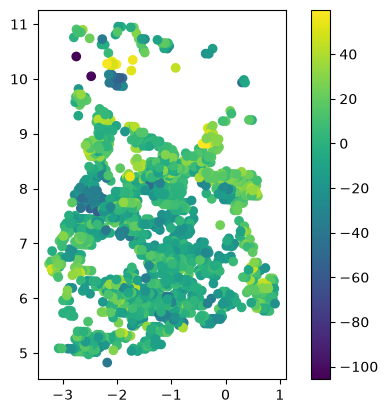

In [64]:
gha_methane = gpd.sjoin(methane_agg, gha_bounds, how="inner", predicate="intersects")
# Map the methane data within Ghana boundaries
gha_methane.plot(column='mean_ch4_anomaly', cmap='viridis', legend=True)

## Extract and map carbon data

In [65]:
carbon_data = pd.read_csv(carbon_file)
carbon_data.head(10)

,year,month,ngfed_id,xco2,xco2_anomaly,x,y,yearmonth
0,2024,7,1091,416.038391,NaN,-27.125,82.125,2024-07
1,2024,7,1092,416.479515,NaN,-26.875,82.125,2024-07
2,2024,7,1094,418.285858,NaN,-26.375,82.125,2024-07
3,2024,7,1095,418.344727,NaN,-26.125,82.125,2024-07
4,2024,7,1096,417.126404,NaN,-25.875,82.125,2024-07
5,2015,6,1121,396.628876,NaN,-91.125,81.875,2015-06
6,2016,7,1121,396.591339,NaN,-91.125,81.875,2016-07
7,2020,6,1121,409.818298,NaN,-91.125,81.875,2020-06
8,2020,7,1121,407.431107,NaN,-91.125,81.875,2020-07
9,2024,7,1121,414.170319,NaN,-91.125,81.875,2024-07


In [66]:
# For each row of the carbon data, identify the corresponding H3 hexagon at a given resolution
h3_resolution = 6  # Example resolution
carbon_data["h3_index"] = carbon_data.apply(
    lambda row: h3.latlng_to_cell(row["y"], row["x"], h3_resolution), axis=1
)
carbon_data.head()

,year,month,ngfed_id,xco2,xco2_anomaly,x,y,yearmonth,h3_index
0,2024,7,1091,416.038391,NaN,-27.125,82.125,2024-07,860068287ffffff
1,2024,7,1092,416.479515,NaN,-26.875,82.125,2024-07,860068297ffffff
2,2024,7,1094,418.285858,NaN,-26.375,82.125,2024-07,86006874fffffff
3,2024,7,1095,418.344727,NaN,-26.125,82.125,2024-07,860068747ffffff
4,2024,7,1096,417.126404,NaN,-25.875,82.125,2024-07,860068747ffffff


In [67]:
# create a pivot table of year month to summarize the xco2 columns
# The pivot table isn't really the answer
def agg_ignore_nan(x):
    return np.nanmean(x)

carbon_agg = pd.pivot_table(carbon_data, index="h3_index", columns=['year'], values=['xco2'], aggfunc=agg_ignore_nan)
# Collapse double column names into single level
carbon_agg.reset_index(inplace=True)
new_columns = [str(x[0]) + str(x[1]) for x in carbon_agg.columns.values]
carbon_agg.columns = new_columns
carbon_agg['geometry'] = carbon_agg['h3_index'].map(lambda h3_index: Point(h3.cell_to_latlng(h3_index)))
carbon_agg = gpd.GeoDataFrame(carbon_agg, geometry='geometry', crs=4326)
# Calculate the most recent carbon number for each row
carbon_agg['most_recent_xco2'] = carbon_agg.loc[:, [col for col in carbon_agg.columns if col.startswith('xco2')]].apply(lambda x: x.dropna().iloc[-1], axis=1)
carbon_agg.head(10)

,h3_index,xco22014,xco22015,xco22016,xco22017,xco22018,xco22019,xco22020,xco22021,xco22022,xco22023,xco22024,geometry,most_recent_xco2
0,860001b9fffffff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,410.304901,NaN,POINT (80.11883 32.72672),410.304901
1,86000594fffffff,NaN,NaN,400.910530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (78.85651 30.29585),400.910530
2,860005a37ffffff,NaN,NaN,401.676724,NaN,406.744183,NaN,NaN,NaN,NaN,NaN,NaN,POINT (79.14718 30.41224),406.744183
3,860005b1fffffff,NaN,NaN,401.822184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (79.10283 30.24074),401.822184
4,860018117ffffff,NaN,395.050423,400.162109,NaN,NaN,NaN,NaN,NaN,413.705475,NaN,415.611994,POINT (80.87802 50.26625),415.611994
5,860018127ffffff,NaN,393.386414,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,413.257660,POINT (80.873 49.63011),413.257660
6,860018137ffffff,NaN,393.557434,399.519201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,415.239044,POINT (80.84587 49.96582),415.239044
7,860018877ffffff,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,407.295807,406.330415,NaN,POINT (80.88527 48.02206),406.330415
8,8600188d7ffffff,NaN,393.708551,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (80.8998 49.29254),393.708551
9,8600188f7ffffff,NaN,395.399963,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (80.86688 48.99537),395.399963


<Axes: >

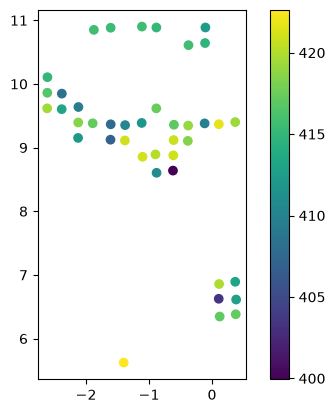

In [68]:
gha_carbon = gpd.sjoin(carbon_agg, gha_bounds, how="inner", predicate="intersects")
# Map the methane data within Ghana boundaries

gha_carbon.plot(column='most_recent_xco2', cmap='viridis', legend=True)

In [ ]:
import xyzservices.providers as xyz


gha_methane.explore(column='mean_ch4_anomaly', marker_kwds=dict(radius=5),
                   tiles=xyz.Esri.WorldGrayCanvas).save("gha_methane_anomaly_map.html")
gha_methane.explore(column='mean_ch4', marker_kwds=dict(radius=5),
                   tiles=xyz.Esri.WorldGrayCanvas).save("gha_methane_mean_map.html")
gha_carbon.explore(column='most_recent_xco2', marker_kwds=dict(radius=10),
                   tiles=xyz.Esri.WorldGrayCanvas).save("gha_carbon_map.html")

In [74]:
xyz.Esri

{'WorldStreetMap': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Street_Map',
  'html_attribution': 'Tiles &copy; Esri &mdash; Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012',
  'attribution': 'Tiles (C) Esri -- Source: Esri, DeLorme, NAVTEQ, USGS, Intermap, iPC, NRCAN, Esri Japan, METI, Esri China (Hong Kong), Esri (Thailand), TomTom, 2012',
  'name': 'Esri.WorldStreetMap'},
 'WorldTopoMap': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Topo_Map',
  'html_attribution': 'Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community',
  'attribution': 'Tiles (C) Esri -- Esri, DeLorme, NAVTEQ, TomTom, Intermap, iPC, USGS, FAO, NPS, NRCAN, GeoBase, Kadaster NL, Ordnance Survey, Esri Japan, METI, Esri China (Hong Kong), and the GIS User Community',
  'name': 'Esri.WorldTopoMap'},
 'WorldImagery': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Imagery',
  'html_attribution': 'Tiles &copy; Esri &mdash; Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
  'attribution': 'Tiles (C) Esri -- Source: Esri, i-cubed, USDA, USGS, AEX, GeoEye, Getmapping, Aerogrid, IGN, IGP, UPR-EGP, and the GIS User Community',
  'name': 'Esri.WorldImagery'},
 'WorldTerrain': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Terrain_Base',
  'html_attribution': 'Tiles &copy; Esri &mdash; Source: USGS, Esri, TANA, DeLorme, and NPS',
  'attribution': 'Tiles (C) Esri -- Source: USGS, Esri, TANA, DeLorme, and NPS',
  'max_zoom': 13,
  'name': 'Esri.WorldTerrain'},
 'WorldShadedRelief': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Shaded_Relief',
  'html_attribution': 'Tiles &copy; Esri &mdash; Source: Esri',
  'attribution': 'Tiles (C) Esri -- Source: Esri',
  'max_zoom': 13,
  'name': 'Esri.WorldShadedRelief'},
 'WorldPhysical': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'World_Physical_Map',
  'html_attribution': 'Tiles &copy; Esri &mdash; Source: US National Park Service',
  'attribution': 'Tiles (C) Esri -- Source: US National Park Service',
  'max_zoom': 8,
  'name': 'Esri.WorldPhysical'},
 'OceanBasemap': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'Ocean/World_Ocean_Base',
  'html_attribution': 'Tiles &copy; Esri &mdash; Sources: GEBCO, NOAA, CHS, OSU, UNH, CSUMB, National Geographic, DeLorme, NAVTEQ, and Esri',
  'attribution': 'Tiles (C) Esri -- Sources: GEBCO, NOAA, CHS, OSU, UNH, CSUMB, National Geographic, DeLorme, NAVTEQ, and Esri',
  'max_zoom': 13,
  'name': 'Esri.OceanBasemap'},
 'NatGeoWorldMap': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'NatGeo_World_Map',
  'html_attribution': 'Tiles &copy; Esri &mdash; National Geographic, Esri, DeLorme, NAVTEQ, UNEP-WCMC, USGS, NASA, ESA, METI, NRCAN, GEBCO, NOAA, iPC',
  'attribution': 'Tiles (C) Esri -- National Geographic, Esri, DeLorme, NAVTEQ, UNEP-WCMC, USGS, NASA, ESA, METI, NRCAN, GEBCO, NOAA, iPC',
  'max_zoom': 16,
  'name': 'Esri.NatGeoWorldMap'},
 'WorldGrayCanvas': {'url': 'https://server.arcgisonline.com/ArcGIS/rest/services/{variant}/MapServer/tile/{z}/{y}/{x}',
  'variant': 'Canvas/World_Light_Gray_Base',
  'html_attribution': 'Tiles &copy; Esri &mdash; Esri, DeLorme, NAVTEQ',
  'attribution': 'Tiles (C) Esri -- Esri, DeLorme, NAVTE